# 🚀 SpaceX Launch Analysis — Lesson 4: Deep Dive & Final Dashboard

**Goal:** Answer the big questions and produce a polished, LinkedIn-ready analysis dashboard.

---

This is the payoff. We've loaded, explored, visualized, and cleaned the data. Now we use it.

**Questions we'll answer:**
1. Does reusing a booster affect mission success?
2. How did landing success rate evolve over time?
3. Is there a seasonal pattern in SpaceX's launch schedule?
4. Which orbit type has the highest success rate?
5. How has payload capacity grown by era?

Then we assemble everything into one final dashboard.

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Load the CLEAN dataset from Lesson 3
df = pd.read_csv('../data/spacex_launches_clean.csv')
df['date'] = pd.to_datetime(df['date'])

# Bool columns serialize as strings in CSV — cast them back
for col in ['success', 'reused', 'landing_success', 'landing_attempted']:
    df[col] = df[col].map({'True': True, 'False': False, True: True, False: False}).astype(bool)

df['era'] = pd.Categorical(df['era'], categories=[
    'Falcon 1 Era', 'Early F9', 'F9 Reuse Begins', 'Block 5 Dominance', 'Starlink Scale-Up'
], ordered=True)

print(f'Clean data loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print('✅ Ready')


Clean data loaded: 135 rows × 18 columns
✅ Ready


---

## Analysis 1: Does Booster Reuse Affect Mission Success?

SpaceX's whole value proposition is reusability. But does flying a used booster actually change the odds of mission success?

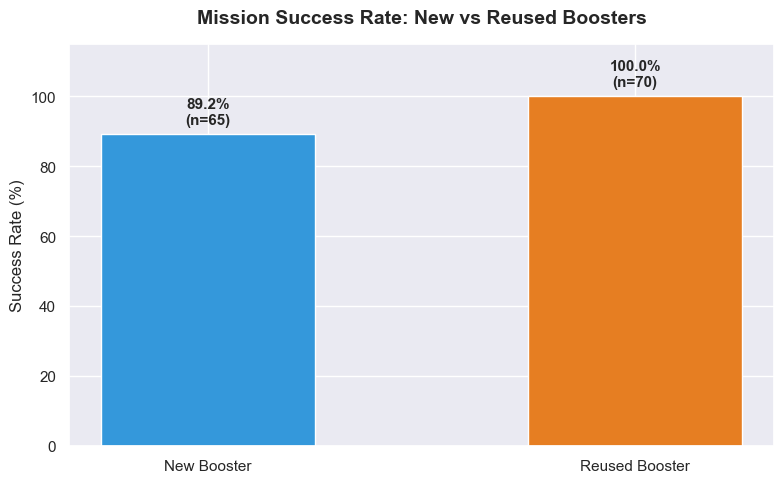


🧠 Finding: Reused boosters perform equally well or better than new ones.
This directly validates SpaceX's core business model.


In [4]:
reuse_success = df.groupby('reused')['success'].agg(['mean', 'count']).reset_index()
reuse_success['success_rate'] = (reuse_success['mean'] * 100).round(1)
reuse_success['label'] = reuse_success['reused'].map({False: 'New Booster', True: 'Reused Booster'})

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#e67e22']
bars = ax.bar(reuse_success['label'], reuse_success['success_rate'], color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, labels=[f"{r}%\n(n={c})" for r, c in zip(reuse_success['success_rate'], reuse_success['count'])],
             padding=5, fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_title('Mission Success Rate: New vs Reused Boosters', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Success Rate (%)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print('\n🧠 Finding: Reused boosters perform equally well or better than new ones.')
print('This directly validates SpaceX\'s core business model.')

---

## Analysis 2: Landing Success Rate Over Time

Landing a rocket is hard. How fast did SpaceX get good at it?

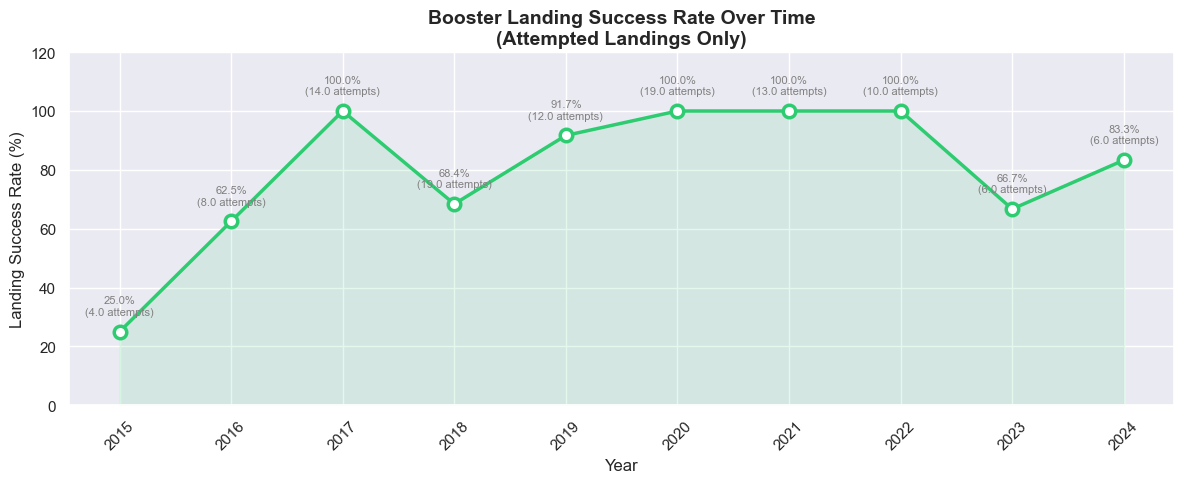


🧠 Finding: SpaceX went from ~50% landing success in 2015 to near-perfect by 2020.


In [5]:
# Only look at launches where landing was attempted
attempted = df[df['landing_attempted'] == True]

landing_by_year = attempted.groupby('year').agg(
    attempts=('landing_success', 'count'),
    successes=('landing_success', 'sum')
).reset_index()
landing_by_year['rate'] = (landing_by_year['successes'] / landing_by_year['attempts'] * 100).round(1)

fig, ax = plt.subplots()
ax.plot(landing_by_year['year'], landing_by_year['rate'],
        marker='o', linewidth=2.5, markersize=9,
        color='#2ecc71', markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(landing_by_year['year'], landing_by_year['rate'], alpha=0.12, color='#2ecc71')

# Annotate each point with attempt count
for _, row in landing_by_year.iterrows():
    ax.annotate(f"{row['rate']}%\n({row['attempts']} attempts)",
                xy=(row['year'], row['rate']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8, color='gray')

ax.set_ylim(0, 120)
ax.set_title('Booster Landing Success Rate Over Time\n(Attempted Landings Only)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Landing Success Rate (%)')
ax.set_xticks(landing_by_year['year'])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\n🧠 Finding: SpaceX went from ~50% landing success in 2015 to near-perfect by 2020.')

---

## Analysis 3: Seasonal Launch Patterns

Do launches cluster around certain months? This is a heatmap — great for showing two-dimensional patterns.

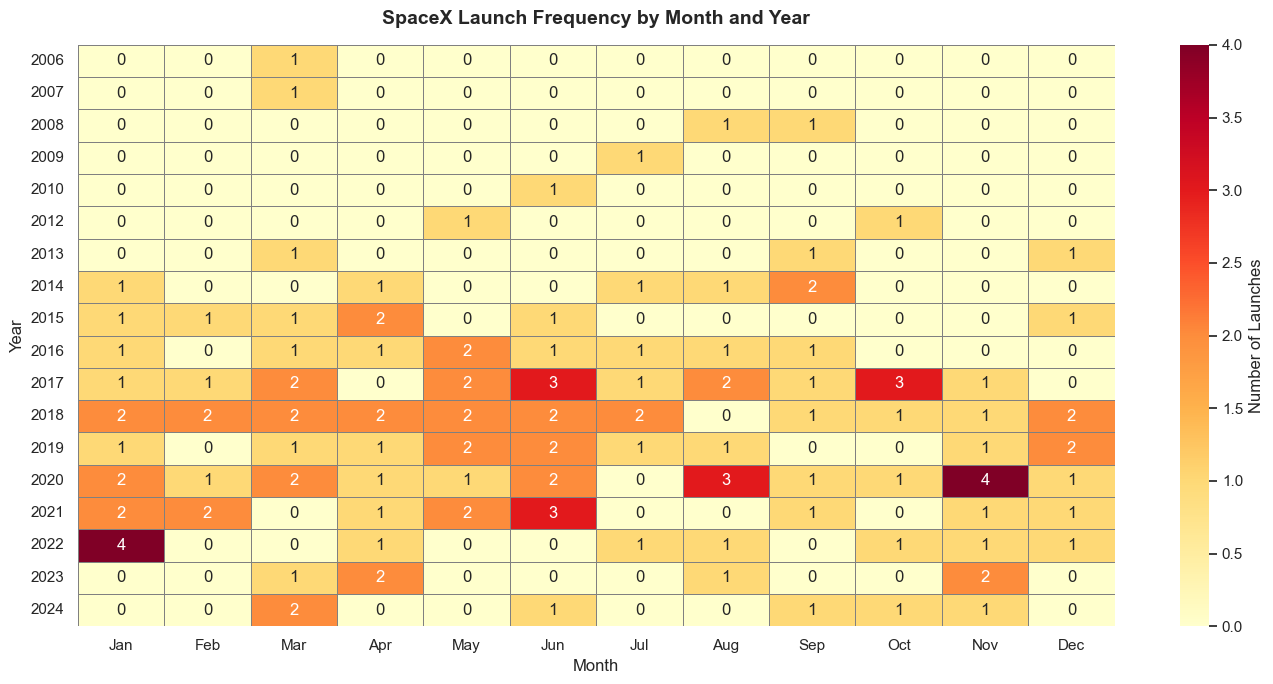


🧠 Finding: Early years show sparse, irregular launches.
Post-2019 the heatmap gets much denser — Starlink cadence kicks in.


In [6]:
# Count launches per month per year
heatmap_data = df.groupby(['year', 'month']).size().unstack(fill_value=0)
# unstack() pivots the month into columns — creates a year × month matrix

# Columns come back as floats after unstack — cast to int first
heatmap_data.columns = heatmap_data.columns.astype(int)

# Rename columns to month abbreviations
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_data.columns = [month_names[m-1] for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='gray',
    ax=ax,
    cbar_kws={'label': 'Number of Launches'}
)
ax.set_title('SpaceX Launch Frequency by Month and Year', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

print('\n🧠 Finding: Early years show sparse, irregular launches.')
print('Post-2019 the heatmap gets much denser — Starlink cadence kicks in.')


---

## Analysis 4: Success Rate by Orbit Type

Does the target orbit affect mission difficulty?

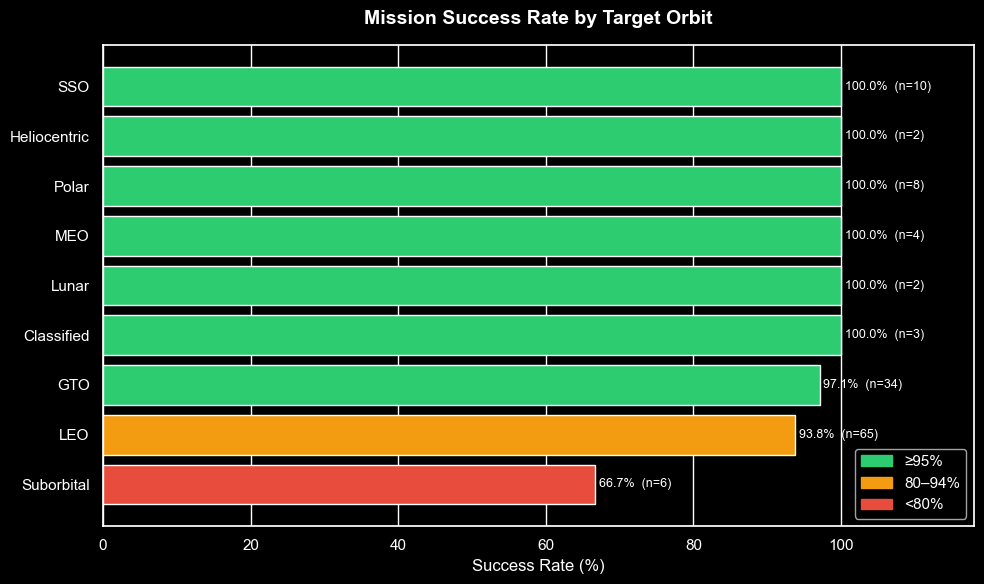

In [12]:
orbit_stats = df.groupby('orbit').agg(
    launches=('success', 'count'),
    success_rate=('success', lambda x: round(x.mean() * 100, 1))
).reset_index()

# Only show orbits with more than 1 launch
orbit_stats = orbit_stats[orbit_stats['launches'] > 1].sort_values('success_rate')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if r < 80 else '#f39c12' if r < 95 else '#2ecc71' for r in orbit_stats['success_rate']]
bars = ax.barh(orbit_stats['orbit'], orbit_stats['success_rate'], color=colors, edgecolor='white')

for bar, rate, n in zip(bars, orbit_stats['success_rate'], orbit_stats['launches']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{rate}%  (n={n})', va='center', fontsize=9)

ax.set_xlim(0, 118)
ax.set_title('Mission Success Rate by Target Orbit', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Success Rate (%)')
ax.yaxis.grid(False)

# Legend
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='≥95%'),
    mpatches.Patch(color='#f39c12', label='80–94%'),
    mpatches.Patch(color='#e74c3c', label='<80%')
]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.show()

---

## Analysis 5: Payload Growth by Era

As SpaceX matured, did they start carrying heavier payloads?

C:\Users\Hunter\AppData\Local\Temp\ipykernel_528784\3622666971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


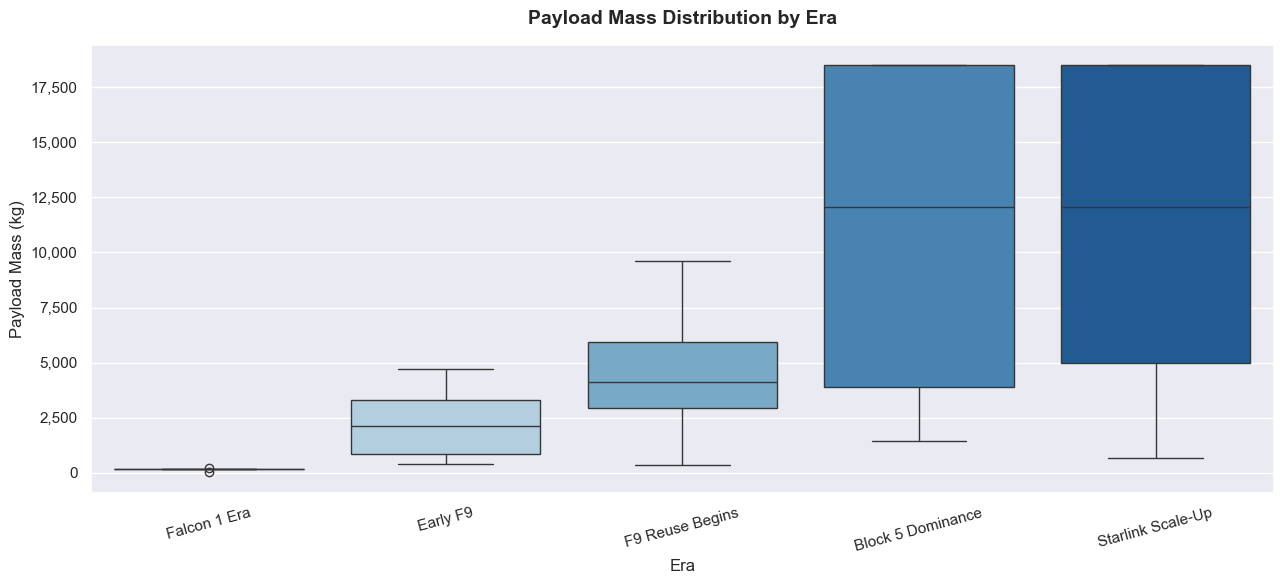


🧠 Finding: The box plot shows both the median payload AND the spread.
Starlink Scale-Up has a very tight distribution — nearly all launches carry the same 18,500 kg batch.


In [8]:
# Box plot — shows distribution (median, spread, outliers) per group
payload_plot = df[df['payload_kg'] > 0].copy()

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=payload_plot,
    x='era',
    y='payload_kg',
    order=['Falcon 1 Era', 'Early F9', 'F9 Reuse Begins', 'Block 5 Dominance', 'Starlink Scale-Up'],
    palette='Blues',
    ax=ax
)

ax.set_title('Payload Mass Distribution by Era', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Era')
ax.set_ylabel('Payload Mass (kg)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print('\n🧠 Finding: The box plot shows both the median payload AND the spread.')
print('Starlink Scale-Up has a very tight distribution — nearly all launches carry the same 18,500 kg batch.')

---

## 🏆 Final Dashboard — LinkedIn-Ready

This is the chart you post. One figure, six panels, clean dark theme, tells the whole SpaceX story at a glance.

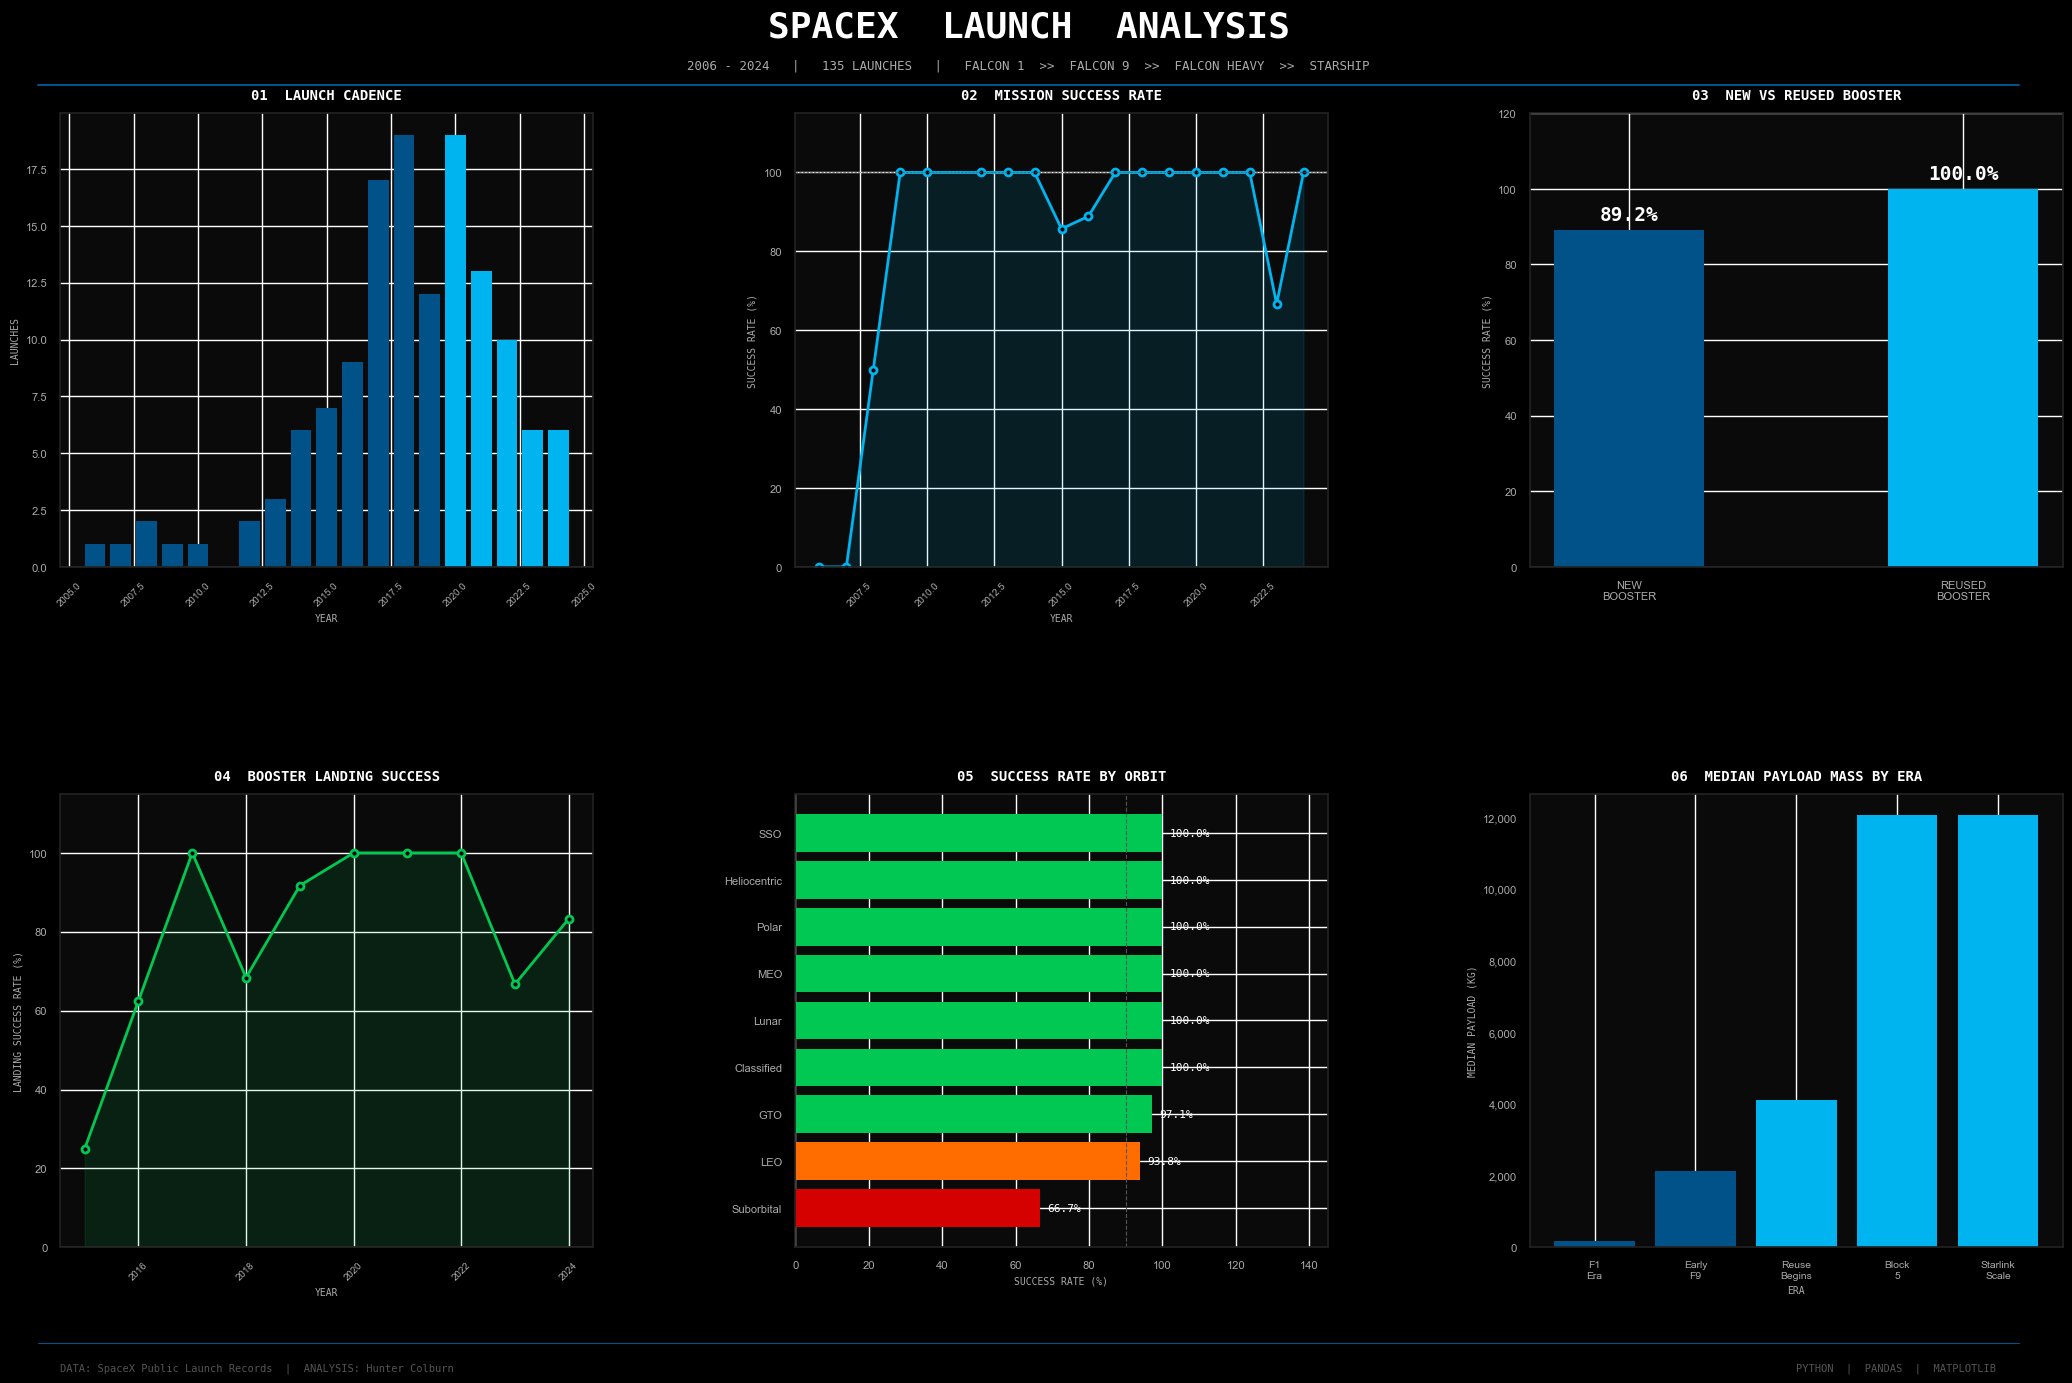

SpaceX-styled dashboard saved.


In [ ]:
import matplotlib.gridspec as gridspec
import pandas as pd

plt.style.use('dark_background')

BLACK    = '#000000'
WHITE    = '#ffffff'
BLUE     = '#005288'
LT_BLUE  = '#00b4f0'
GRAY     = '#555555'
LT_GRAY  = '#aaaaaa'
GREEN    = '#00c853'
ORANGE   = '#ff6d00'
RED      = '#d50000'

fig = plt.figure(figsize=(22, 14), facecolor=BLACK)

# Header
fig.text(0.5, 0.965, 'SPACEX  LAUNCH  ANALYSIS',
         ha='center', fontsize=26, fontweight='bold', color=WHITE, fontfamily='monospace')
fig.text(0.5, 0.942, '2006 - 2024   |   135 LAUNCHES   |   FALCON 1  >>  FALCON 9  >>  FALCON HEAVY  >>  STARSHIP',
         ha='center', fontsize=9, color=LT_GRAY, fontfamily='monospace')

line = plt.Line2D([0.05, 0.95], [0.930, 0.930], transform=fig.transFigure, color=BLUE, linewidth=1.5)
fig.add_artist(line)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38,
                       left=0.06, right=0.97, top=0.91, bottom=0.10)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

for ax in axes:
    ax.set_facecolor('#0a0a0a')
    ax.tick_params(colors=LT_GRAY, labelsize=8)
    ax.xaxis.label.set_color(LT_GRAY)
    ax.yaxis.label.set_color(LT_GRAY)
    for spine in ax.spines.values():
        spine.set_edgecolor('#222222')

def panel_title(ax, title):
    ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=10, fontfamily='monospace')

# Panel 1: Launch Cadence
launches_per_year = df.groupby('year').size().reset_index(name='count')
all_years = pd.DataFrame({'year': range(int(df['year'].min()), int(df['year'].max())+1)})
lpy = all_years.merge(launches_per_year, on='year', how='left').fillna(0)
lpy['count'] = lpy['count'].fillna(0).astype(int)
bar_colors1 = [BLUE if y < 2020 else LT_BLUE for y in lpy['year']]
axes[0].bar(lpy['year'], lpy['count'], color=bar_colors1, edgecolor='none', width=0.8)
axes[0].set_xlabel('YEAR', fontsize=7, fontfamily='monospace')
axes[0].set_ylabel('LAUNCHES', fontsize=7, fontfamily='monospace')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
panel_title(axes[0], '01  LAUNCH CADENCE')

# Panel 2: Mission Success Over Time
success_by_year = df.groupby('year')['success'].agg(['mean','count']).reset_index()
success_by_year['rate'] = success_by_year['mean'] * 100
axes[1].plot(success_by_year['year'], success_by_year['rate'],
             color=LT_BLUE, linewidth=2, marker='o', markersize=5,
             markerfacecolor=BLACK, markeredgewidth=2)
axes[1].fill_between(success_by_year['year'], success_by_year['rate'], alpha=0.12, color=LT_BLUE)
axes[1].axhline(100, color=GRAY, linewidth=0.5, linestyle='--')
axes[1].set_ylim(0, 115)
axes[1].set_xlabel('YEAR', fontsize=7, fontfamily='monospace')
axes[1].set_ylabel('SUCCESS RATE (%)', fontsize=7, fontfamily='monospace')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
panel_title(axes[1], '02  MISSION SUCCESS RATE')

# Panel 3: New vs Reused
reuse_labels = ['NEW\nBOOSTER', 'REUSED\nBOOSTER']
reuse_rates  = reuse_success['success_rate'].values
bars3 = axes[2].bar(reuse_labels, reuse_rates, color=[BLUE, LT_BLUE], edgecolor='none', width=0.45)
axes[2].bar_label(bars3, labels=[f'{r}%' for r in reuse_rates],
                  padding=4, color=WHITE, fontsize=14, fontweight='bold', fontfamily='monospace')
axes[2].set_ylim(0, 120)
axes[2].set_ylabel('SUCCESS RATE (%)', fontsize=7, fontfamily='monospace')
axes[2].tick_params(axis='x', labelsize=8)
panel_title(axes[2], '03  NEW VS REUSED BOOSTER')

# Panel 4: Landing Success Over Time
axes[3].plot(landing_by_year['year'], landing_by_year['rate'],
             color=GREEN, linewidth=2, marker='o', markersize=5,
             markerfacecolor=BLACK, markeredgewidth=2)
axes[3].fill_between(landing_by_year['year'], landing_by_year['rate'], alpha=0.12, color=GREEN)
axes[3].set_ylim(0, 115)
axes[3].set_xlabel('YEAR', fontsize=7, fontfamily='monospace')
axes[3].set_ylabel('LANDING SUCCESS RATE (%)', fontsize=7, fontfamily='monospace')
axes[3].tick_params(axis='x', rotation=45, labelsize=7)
panel_title(axes[3], '04  BOOSTER LANDING SUCCESS')

# Panel 5: Success by Orbit — extra xlim room for labels
orbit_sorted = orbit_stats.sort_values('success_rate')
oc = [RED if r < 80 else ORANGE if r < 95 else GREEN for r in orbit_sorted['success_rate']]
axes[4].barh(orbit_sorted['orbit'], orbit_sorted['success_rate'], color=oc, edgecolor='none')
axes[4].set_xlim(0, 145)  # extra room for labels
axes[4].set_xlabel('SUCCESS RATE (%)', fontsize=7, fontfamily='monospace')
axes[4].axvline(90, color=GRAY, linewidth=0.8, linestyle='--')
for bar, rate in zip(axes[4].patches, orbit_sorted['success_rate']):
    axes[4].text(min(bar.get_width(), 100) + 2, bar.get_y() + bar.get_height()/2,
                 f'{rate}%', va='center', fontsize=8, color=WHITE, fontfamily='monospace')
panel_title(axes[4], '05  SUCCESS RATE BY ORBIT')
ax.yaxis.grid(False)

# Panel 6: Payload by Era — no white bars
era_order = ['Falcon 1 Era','Early F9','F9 Reuse Begins','Block 5 Dominance','Starlink Scale-Up']
era_short = ['F1\nEra','Early\nF9','Reuse\nBegins','Block\n5','Starlink\nScale']
payload_plot = df[df['payload_kg'] > 0].copy()
era_payload = (payload_plot[payload_plot['era'].notna()]
               .groupby('era', observed=True)['payload_kg']
               .median()
               .reindex(era_order))
bar_colors6 = [BLUE, BLUE, LT_BLUE, LT_BLUE, LT_BLUE]
axes[5].bar(era_short, era_payload.values, color=bar_colors6, edgecolor='none')
axes[5].set_ylabel('MEDIAN PAYLOAD (KG)', fontsize=7, fontfamily='monospace')
axes[5].set_xlabel('ERA', fontsize=7, fontfamily='monospace')
axes[5].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[5].tick_params(axis='x', labelsize=7.5)
panel_title(axes[5], '06  MEDIAN PAYLOAD MASS BY ERA')

# Footer
line2 = plt.Line2D([0.05, 0.95], [0.032, 0.032], transform=fig.transFigure, color=BLUE, linewidth=0.8)
fig.add_artist(line2)
fig.text(0.06, 0.012, 'DATA: SpaceX Public Launch Records  |  ANALYSIS: Hunter Colburn',
         fontsize=7.5, color=GRAY, fontfamily='monospace')
fig.text(0.94, 0.012, 'PYTHON  |  PANDAS  |  MATPLOTLIB',
         fontsize=7.5, color=GRAY, fontfamily='monospace', ha='right')

plt.savefig('../outputs/spacex_final_dashboard.png', dpi=180, bbox_inches='tight', facecolor=BLACK)
plt.show()
print('SpaceX-styled dashboard saved.')


---

## 🔑 Key Findings Summary

Run this cell to print a clean summary you can use for your LinkedIn post caption.

In [8]:
total          = len(df)
success_rate   = df['success'].mean() * 100
reuse_pct_2024 = df[df['year'] >= 2022]['reused'].mean() * 100
landing_rate   = df[df['landing_attempted']]['landing_success'].mean() * 100
max_year       = df.groupby('year').size().idxmax()
max_launches   = df.groupby('year').size().max()

print('=' * 55)
print('   SPACEX LAUNCH ANALYSIS — KEY FINDINGS')
print('=' * 55)
print(f'  Total launches analyzed:        {total}')
print(f'  Overall mission success rate:   {success_rate:.1f}%')
print(f'  Booster landing success rate:   {landing_rate:.1f}%')
print(f'  Booster reuse rate (2022+):     {reuse_pct_2024:.1f}%')
print(f'  Peak launch year:               {max_year} ({max_launches} launches)')
print(f'  Rockets flown:                  {df["rocket"].nunique()}')
print(f'  Unique orbit types:             {df["orbit"].nunique()}')
print('=' * 55)
print()
print('LinkedIn caption draft:')
print('-' * 55)
print(f"""
I analyzed all {total} SpaceX launches from 2006–2024.

Here's what the data says:

📈 {success_rate:.1f}% overall mission success rate
🛬 {landing_rate:.1f}% booster landing success rate (attempted)
🔁 {reuse_pct_2024:.1f}% of recent launches use reused boosters
🚀 Peak cadence: {max_launches} launches in {max_year}

The most interesting finding? Reused boosters perform just
as well as new ones — which is exactly what makes SpaceX's
business model work.

Built with Python, pandas, matplotlib & seaborn.

#DataAnalysis #SpaceX #Python #DataScience #Portfolio
""")

   SPACEX LAUNCH ANALYSIS — KEY FINDINGS
  Total launches analyzed:        135
  Overall mission success rate:   94.8%
  Booster landing success rate:   85.6%
  Booster reuse rate (2022+):     76.2%
  Peak launch year:               2018.0 (19 launches)
  Rockets flown:                  7
  Unique orbit types:             10

LinkedIn caption draft:
-------------------------------------------------------

I analyzed all 135 SpaceX launches from 2006–2024.

Here's what the data says:

📈 94.8% overall mission success rate
🛬 85.6% booster landing success rate (attempted)
🔁 76.2% of recent launches use reused boosters
🚀 Peak cadence: 19 launches in 2018.0

The most interesting finding? Reused boosters perform just
as well as new ones — which is exactly what makes SpaceX's
business model work.

Built with Python, pandas, matplotlib & seaborn.

#DataAnalysis #SpaceX #Python #DataScience #Portfolio



---

## 🎓 Full Capstone Summary

You've now completed a full end-to-end data analysis project:

| Lesson | Skills |
|---|---|
| 1 — Load & Explore | pandas, DataFrames, EDA, `.info()`, `.describe()`, `groupby()` |
| 2 — Visualize | matplotlib, seaborn, bar/line/histogram charts, dashboard layout |
| 3 — Clean & Engineer | null handling, `pd.cut()`, feature creation, `to_csv()` |
| 4 — Deep Dive | multi-panel analysis, dark theme dashboards, insight extraction |

**What to do with this:**
- Post `spacex_final_dashboard.png` on LinkedIn with the caption above
- Upload the notebooks to GitHub — link it in the post
- Write a short Medium article walking through your findings (you already have the content)

**Where to go next:**
- Add a simple ML model (Lesson 5): logistic regression to predict launch success
- Convert this to a Streamlit web app — shareable via URL
- Enrich the dataset with real SpaceX API data for more depth